## Exploratory Data Analysis (EDA) and Machine Learning on Agricultural Yield Dataset

##Import Libraries

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Part A: Understanding the Dataset
###Q1. Dataset Overview

1. How many rows and columns are present?

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/mahiich07/Agricultural-Yield-EDA-ML/refs/heads/main/agriculture_ml_dataset_cw.csv"

df = pd.read_csv(url)

df.shape

(2020, 11)

2. What are the names of all columns?

In [5]:
df.columns

Index(['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation',
       'Fertilizer', 'Rainfall', 'Temperature', 'Humidity', 'Nitrogen',
       'Yield'],
      dtype='object')

3. Display the first 10 records.

In [6]:
df.head(10)

,Crop_Type,Soil_Type,Region,Season,Irrigation,Fertilizer,Rainfall,Temperature,Humidity,Nitrogen,Yield
0,Wheat,Silty,South,Kharif,Sprinkler,Chemical,93.7,22.9,69.0,115.0,5.13
1,Cotton,NaN,West,Zaid,Flood,Organic,146.9,25.6,NaN,71.0,5.40
2,Cotton,Clay,North,Kharif,Drip,Chemical,108.7,22.1,NaN,86.0,4.26
3,Maize,Clay,South,Kharif,Sprinkler,Chemical,72.3,26.8,69.4,44.0,4.35
4,Maize,Silty,West,Kharif,Flood,Organic,119.9,26.3,44.3,48.0,4.88
5,Sugarcane,Loamy,West,Rabi,Flood,Mixed,176.4,NaN,83.3,72.0,4.70
6,Wheat,Clay,South,Rabi,Sprinkler,Chemical,146.1,NaN,72.9,97.0,6.82
7,Cotton,Loamy,East,Zaid,NaN,Organic,200.6,26.8,53.6,101.0,6.88
8,Rice,Silty,North,Rabi,Drip,Mixed,136.2,31.3,58.5,111.0,6.26
9,Wheat,Sandy,North,Rabi,Sprinkler,Organic,215.7,26.2,70.8,55.0,6.92


###Q2. Data Types and Missing Values
1. Check the data type of each column.

In [7]:
df.dtypes

,0
Crop_Type,object
Soil_Type,object
Region,object
Season,object
Irrigation,object
Fertilizer,object
Rainfall,float64
Temperature,float64
Humidity,float64
Nitrogen,float64


2. Identify whether any missing values are present.

In [8]:
df.isnull().sum()

,0
Crop_Type,0
Soil_Type,121
Region,0
Season,0
Irrigation,120
Fertilizer,0
Rainfall,121
Temperature,120
Humidity,122
Nitrogen,121


3. If missing values exist, mention the affected columns.

In [9]:
df.columns[df.isnull().any()]

Index(['Soil_Type', 'Irrigation', 'Rainfall', 'Temperature', 'Humidity',
       'Nitrogen'],
      dtype='object')

###Q3. Descriptive Statistics

Generate summary statistics for all numerical features.

In [10]:
df.describe()

,Rainfall,Temperature,Humidity,Nitrogen,Yield
count,1899.000000,1900.000000,1898.000000,1899.000000,2020.000000
mean,129.723960,26.875421,67.740622,79.169036,5.442926
std,35.395931,4.104174,12.046501,22.876734,1.062772
min,22.800000,12.900000,30.600000,40.000000,1.740000
25%,107.100000,24.200000,59.500000,59.000000,4.700000
50%,128.100000,26.900000,67.650000,79.000000,5.430000
75%,153.500000,29.600000,75.800000,99.000000,6.172500
max,245.300000,43.100000,117.800000,119.000000,8.910000


1. Which feature has the highest mean?

In [11]:
df.mean(numeric_only=True).idxmax()

'Rainfall'

2. Which feature has the highest standard deviation?

In [12]:
df.std(numeric_only=True).idxmax()

'Rainfall'

##Part B: Exploratory Data Analysis (EDA)
###Q4. Distribution Analysis

Create histograms for:

rainfall_mm

temperature_c

fertilizer_kg

yield_ton_per_hectare

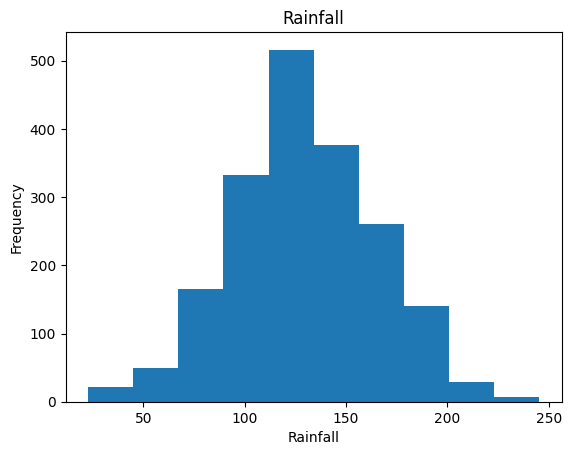

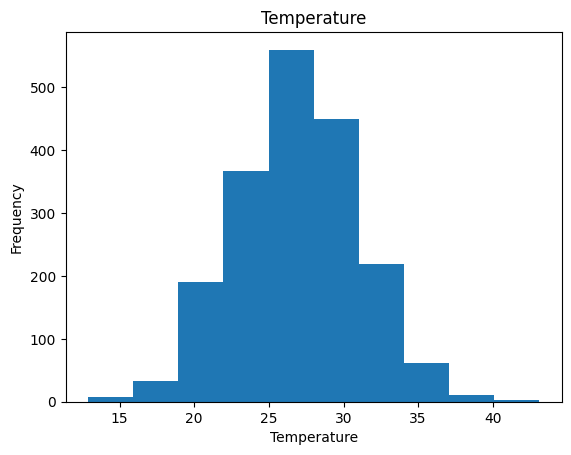

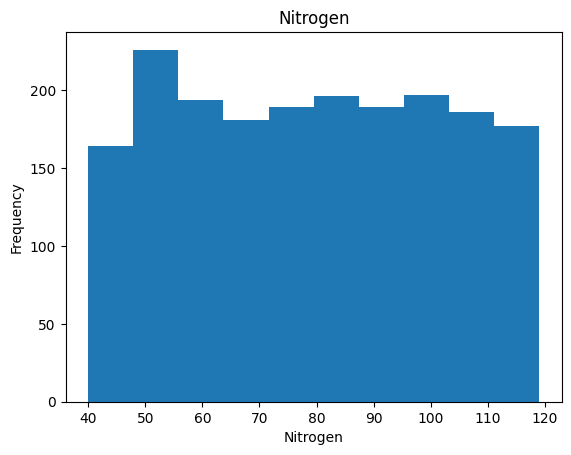

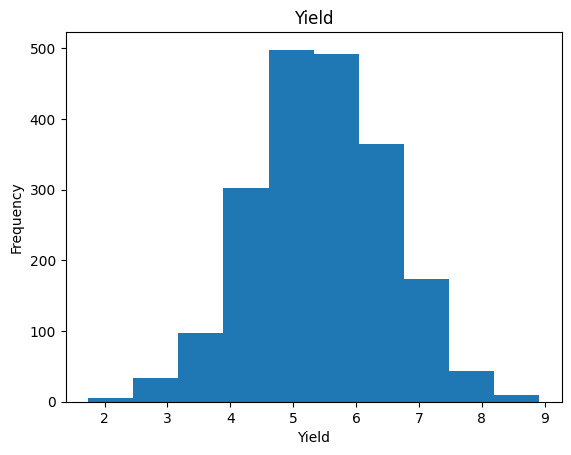

In [16]:
columns = [
    "Rainfall",
    "Temperature",
    "Nitrogen",
    "Yield"
]

for col in columns:
    plt.hist(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

Observations:

Rainfall:
1. Rainfall values are approximately normally distributed.
2. Most rainfall values are concentrated between 100–160 mm.
3. Very low and very high rainfall values occur less frequently.


Temperature:
1. Temperature distribution is approximately normal.
2. Most temperature values lie in the middle range around 25–30°C.
3. Extreme temperature values are less frequent.


Nitrogen:
1. Nitrogen values are widely distributed across the range.
2. The frequency is almost uniform for different nitrogen levels.
3. No major outliers are observed in nitrogen values.


Yield:
1. Yield distribution is approximately normal.
2. Most crop yield values are concentrated between 4 to 7 tons per hectare.
3. Very low and very high yield values are less common.

###Q5. Crop Type Analysis
1. Find the number of records for each crop type.

In [17]:
df['Crop_Type'].value_counts()

,count
Crop_Type,
Maize,426
Wheat,422
Sugarcane,403
Cotton,399
Rice,370


2. Create a count plot (bar chart) for crop_type.

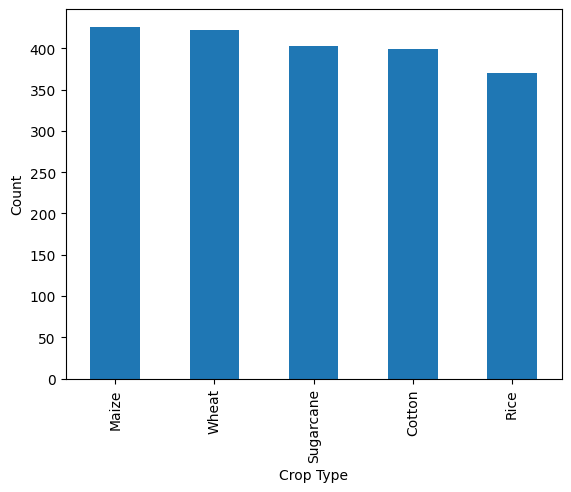

In [18]:
df['Crop_Type'].value_counts().plot(kind='bar')

plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.show()


3. Which crop appears most frequently?

In [19]:
df['Crop_Type'].mode()[0]

'Maize'

###Q6. Soil Type Analysis
1. Find the frequency of each soil type.

In [21]:
df['Soil_Type'].value_counts()

,count
Soil_Type,
Silty,493
Loamy,482
Clay,463
Sandy,461


2. Create a count plot for soil_type.

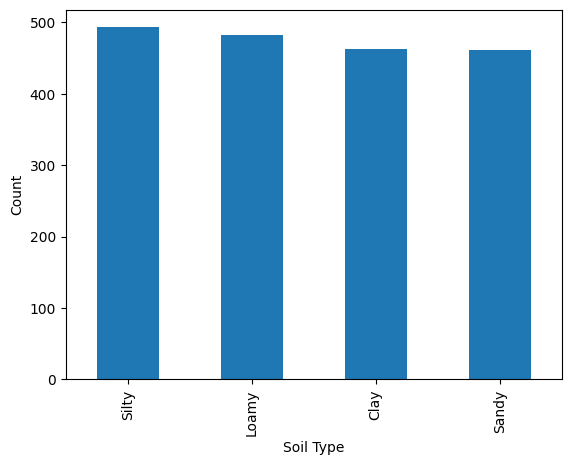

In [20]:
df['Soil_Type'].value_counts().plot(kind='bar')

plt.xlabel("Soil Type")
plt.ylabel("Count")
plt.show()

3. Which soil type is most common?

In [22]:
df['Soil_Type'].mode()[0]

'Silty'

###Q7. Yield Distribution

Create a histogram of yield_ton_per_hectare.

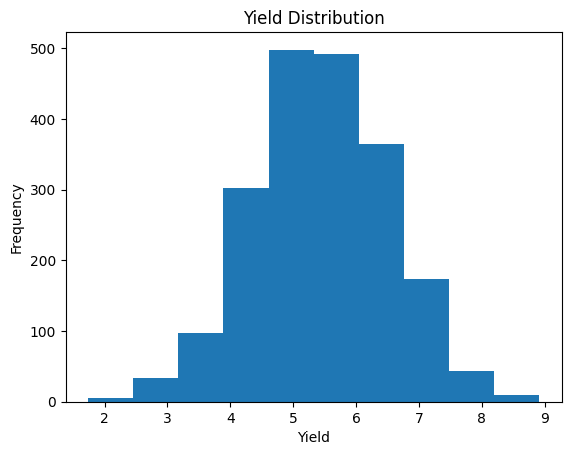

In [23]:
plt.hist(df['Yield'])

plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.title("Yield Distribution")

plt.show()

Observations:

1. The distribution of Yield is approximately normal as most values are concentrated near the center.

2. Most yield values are concentrated between approximately 4 to 7 tons per hectare.

3. Very low yield values below 3 and very high values above 8 occur less frequently.

###Q8. Scatter Plot Analysis
Create scatter plot:
1. rainfall_mm vs yield_ton_per_hectare

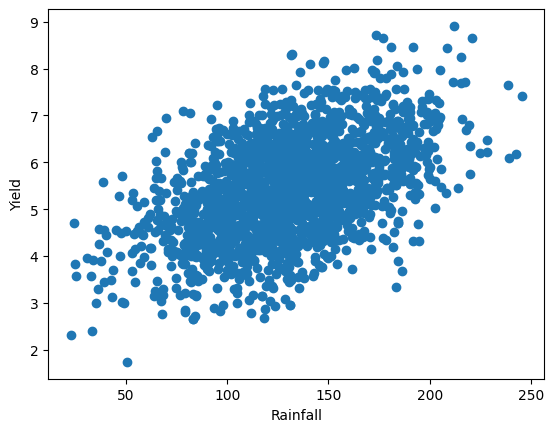

In [24]:
plt.scatter(
    df['Rainfall'],
    df['Yield']
)

plt.xlabel("Rainfall")
plt.ylabel("Yield")

plt.show()

2. fertilizer_kg vs yield_ton_per_hectare

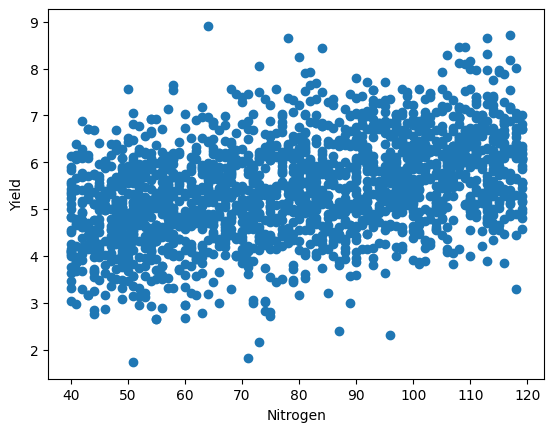

In [25]:
plt.scatter(
    df['Nitrogen'],
    df['Yield']
)

plt.xlabel("Nitrogen")
plt.ylabel("Yield")

plt.show()

###Which feature appears to have a stronger relationship with yield?

1. Rainfall appears to have a stronger relationship with yield compared to nitrogen.

2. The rainfall vs yield scatter plot shows a clearer positive relationship, where yield generally increases as rainfall increases.

3. The nitrogen vs yield plot also shows a slight positive trend, but the points are more widely scattered, indicating a weaker relationship.

###Q9. Correlation Analysis
1. Generate a correlation matrix.

In [36]:
correlation = df.corr(numeric_only=True)

correlation

,Rainfall,Temperature,Humidity,Nitrogen,Yield
Rainfall,1.000000,-0.013519,0.002204,-0.031158,0.498788
Temperature,-0.013519,1.000000,0.007016,0.029948,0.023503
Humidity,0.002204,0.007016,1.000000,0.017116,0.013557
Nitrogen,-0.031158,0.029948,0.017116,1.000000,0.395801
Yield,0.498788,0.023503,0.013557,0.395801,1.000000


2. Create heatmap.

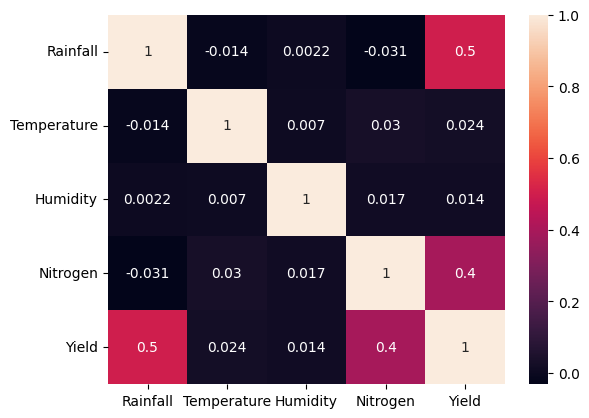

In [37]:
sns.heatmap(correlation, annot=True)

plt.show()

3. Identify top three features most correlated with crop yield.

In [40]:
correlation['Yield'].sort_values(ascending=False)

,Yield
Yield,1.000000
Rainfall,0.498788
Nitrogen,0.395801
Temperature,0.023503
Humidity,0.013557


###Q10. Group-Based Analysis
1.Calculate average yield for each crop type.

In [26]:
df.groupby('Crop_Type')['Yield'].mean()

,Yield
Crop_Type,
Cotton,5.434286
Maize,5.439014
Rice,5.368919
Sugarcane,5.445434
Wheat,5.517536


2. Calculate average yield for each soil type.

In [27]:
df.groupby('Soil_Type')['Yield'].mean()

,Yield
Soil_Type,
Clay,5.509352
Loamy,5.347427
Sandy,5.452777
Silty,5.439919


3. Which crop has the highest average yield?

In [28]:
df.groupby('Crop_Type')['Yield'].mean().idxmax()

'Wheat'

4. Which soil type has the highest average yield?

In [29]:
df.groupby('Soil_Type')['Yield'].mean().idxmax()

'Clay'

##Part C: Data Preparation
###Q11. Feature Encoding
1. Identify categorical columns.

In [32]:
df.select_dtypes(include='object').columns

Index(['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation',
       'Fertilizer'],
      dtype='object')

2. Convert them into numerical form using One-Hot Encoding.

In [33]:
df_encoded = pd.get_dummies(df)

3. Display first five rows of transformed dataset.

In [34]:
df_encoded.head()

,Rainfall,Temperature,Humidity,Nitrogen,Yield,Crop_Type_Cotton,Crop_Type_Maize,Crop_Type_Rice,Crop_Type_Sugarcane,Crop_Type_Wheat,...,Region_West,Season_Kharif,Season_Rabi,Season_Zaid,Irrigation_Drip,Irrigation_Flood,Irrigation_Sprinkler,Fertilizer_Chemical,Fertilizer_Mixed,Fertilizer_Organic
0,93.7,22.9,69.0,115.0,5.13,False,False,False,False,True,...,False,True,False,False,False,False,True,True,False,False
1,146.9,25.6,NaN,71.0,5.40,True,False,False,False,False,...,True,False,False,True,False,True,False,False,False,True
2,108.7,22.1,NaN,86.0,4.26,True,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
3,72.3,26.8,69.4,44.0,4.35,False,True,False,False,False,...,False,True,False,False,False,False,True,True,False,False
4,119.9,26.3,44.3,48.0,4.88,False,True,False,False,False,...,True,True,False,False,False,True,False,False,False,True


###Q12. Feature Selection
Separate:

Input features (X)

Target variable (y)

In [45]:
X = df_encoded.drop(
    'Yield',
    axis=1
)

y = df_encoded['Yield']

# Handling missing values

X = X.fillna(X.mean())
y = y.fillna(y.mean())

###Specify target variable.

Target Variable:

yield_ton_per_hectare

##Part D: Machine Learning
###Q13. Train-Test Split

1. Split the dataset into:

80% Training Data

20% Testing Data

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

2. Display the shape:

In [47]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1616, 26)
(404, 26)
(1616,)
(404,)


###Q14. Linear Regression Model
1. Train a Linear Regression model.

In [48]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

2. Display model coefficients and intercept.

In [49]:
model.coef_

model.intercept_

np.float64(1.7300077806810377)

3. Which feature has the highest positive coefficient?

In [50]:
pd.Series(
    model.coef_,
    index=X.columns
).idxmax()

'Irrigation_Drip'